# Pipeline de Classificação Multiclasse com Dataset Covertype

Este notebook implementa um pipeline completo e executável para classificação multiclasse usando o dataset tabular Covertype do sklearn.datasets.fetch_covtype. É importante ressaltar que este é um dataset tabular, não de imagens.

O pipeline inclui: carregamento de dados, análise exploratória (EDA), preparação de dados, seleção de features, treinamento de múltiplos modelos, avaliação, comparação, seleção do melhor modelo e persistência para reutilização.

**Requisitos:** Python 3, bibliotecas padrão como sklearn, pandas, matplotlib, seaborn. Opcionais: xgboost, tensorflow.

In [1]:
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

# Imports opcionais
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost não disponível, pulando XGBClassifier.')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print('TensorFlow não disponível, pulando redes neurais.')

# Configurações
MODO_RAPIDO = False  # Defina True para usar amostra pequena do dataset
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_FEATURES = 20  # Número de features a selecionar



[TensorFlow DLL Diagnostic] Analyzing: C:\Users\calab\anaconda3\envs\pycaret\lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
TensorFlow não disponível, pulando redes neurais.


In [2]:
def carregar_pipeline_salvo(caminho_artifacts='./artifacts'):
    """Carrega o pipeline salvo: scaler, features selecionadas, modelo."""
    scaler = joblib.load(os.path.join(caminho_artifacts, 'scaler.joblib'))
    with open(os.path.join(caminho_artifacts, 'selected_features.json'), 'r') as f:
        selected_features = json.load(f)
    if os.path.exists(os.path.join(caminho_artifacts, 'best_model.joblib')):
        model = joblib.load(os.path.join(caminho_artifacts, 'best_model.joblib'))
    elif TF_AVAILABLE and os.path.exists(os.path.join(caminho_artifacts, 'best_model.keras')):
        model = tf.keras.models.load_model(os.path.join(caminho_artifacts, 'best_model.keras'))
    else:
        raise FileNotFoundError('Modelo salvo não encontrado.')
    return scaler, selected_features, model

def predizer_novos_dados(X_novo, scaler, selected_features, model):
    """Prediz classes para novos dados usando o pipeline carregado."""
    X_novo = pd.DataFrame(X_novo, columns=selected_features)  # Assumindo colunas corretas
    X_novo_scaled = scaler.transform(X_novo)
    predicoes = model.predict(X_novo_scaled)
    return predicoes


In [3]:
# Carregamento do dataset Covertype
print('Carregando dataset Covertype...')
data = fetch_covtype()
X = pd.DataFrame(data.data, columns=[f'feature_{i}' for i in range(data.data.shape[1])])
y = data.target

# Ajuste y = y - 1: O dataset Covertype tem classes de 1 a 7, mas sklearn espera 0 a 6 para multiclasse.
print('Ajustando labels: y = y - 1 para compatibilidade com sklearn (classes 0-6).')
y = y - 1

if MODO_RAPIDO:
    # Amostra pequena para teste rápido
    sample_size = 10000
    indices = np.random.choice(len(X), sample_size, replace=False)
    X = X.iloc[indices]
    y = y[indices]
    print(f'Usando modo rápido com {sample_size} amostras.')
else:
    print(f'Dataset completo: {len(X)} amostras.')

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')


Carregando dataset Covertype...
Ajustando labels: y = y - 1 para compatibilidade com sklearn (classes 0-6).
Dataset completo: 581012 amostras.
Treino: (464809, 54), Teste: (116203, 54)


## Análise Exploratória de Dados (EDA)

Realizamos EDA com amostragem para evitar problemas computacionais em gráficos pesados.

Distribuição das classes:
1    2389
0    1831
2     358
6     183
5     132
4      87
3      20
Name: count, dtype: int64


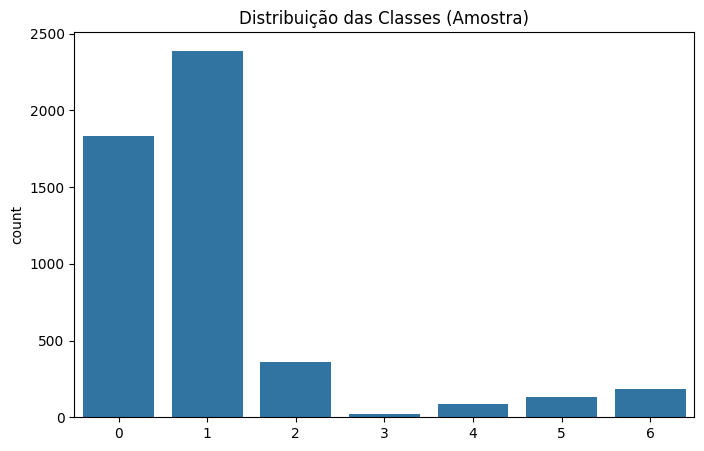

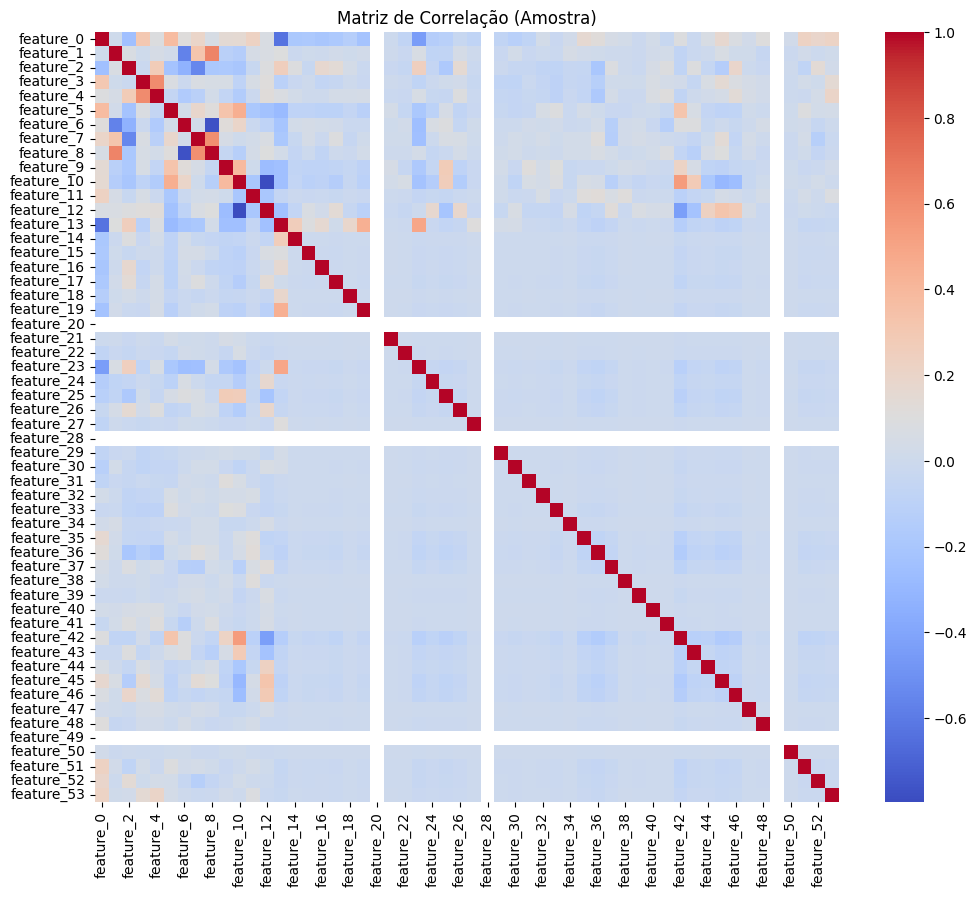

In [4]:
# EDA com amostragem
sample_size_eda = min(5000, len(X_train))
indices_eda = np.random.choice(len(X_train), sample_size_eda, replace=False)
X_eda = X_train.iloc[indices_eda]
y_eda = y_train[indices_eda]

print('Distribuição das classes:')
print(pd.Series(y_eda).value_counts())

# Gráfico de distribuição de classes
plt.figure(figsize=(8, 5))
sns.countplot(x=y_eda)
plt.title('Distribuição das Classes (Amostra)')
plt.show()

# Correlação entre features (amostra)
plt.figure(figsize=(12, 10))
sns.heatmap(X_eda.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de Correlação (Amostra)')
plt.show()


In [5]:
# Preparação de dados: Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Seleção de features
print('Selecionando features...')
selector_f = SelectKBest(score_func=f_classif, k=N_FEATURES)
X_train_f = selector_f.fit_transform(X_train_scaled, y_train)
X_test_f = selector_f.transform(X_test_scaled)

selector_mi = SelectKBest(score_func=mutual_info_classif, k=N_FEATURES)
X_train_mi = selector_mi.fit_transform(X_train_scaled, y_train)
X_test_mi = selector_mi.transform(X_test_scaled)

et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE)
et.fit(X_train_scaled, y_train)
importances = et.feature_importances_
indices_et = np.argsort(importances)[-N_FEATURES:]
X_train_et = X_train_scaled[:, indices_et]
X_test_et = X_test_scaled[:, indices_et]

# Usar f_classif para seleção final (pode ajustar)
selected_features = [f'feature_{i}' for i in selector_f.get_support(indices=True)]
X_train_selected = X_train_f
X_test_selected = X_test_f
print(f'Features selecionadas: {selected_features}')


Selecionando features...
Features selecionadas: ['feature_0', 'feature_2', 'feature_5', 'feature_9', 'feature_10', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_19', 'feature_23', 'feature_25', 'feature_30', 'feature_35', 'feature_36', 'feature_42', 'feature_51', 'feature_52', 'feature_53']


Treinando LogisticRegression...
LogisticRegression: Acc=0.7024, F1=0.4868, Train=54.27s, Inf=0.12s
              precision    recall  f1-score   support

           0       0.69      0.66      0.67     42368
           1       0.72      0.80      0.76     56661
           2       0.65      0.85      0.73      7151
           3       0.57      0.35      0.43       549
           4       0.21      0.01      0.01      1899
           5       0.54      0.17      0.25      3473
           6       0.68      0.46      0.55      4102

    accuracy                           0.70    116203
   macro avg       0.58      0.47      0.49    116203
weighted avg       0.69      0.70      0.69    116203



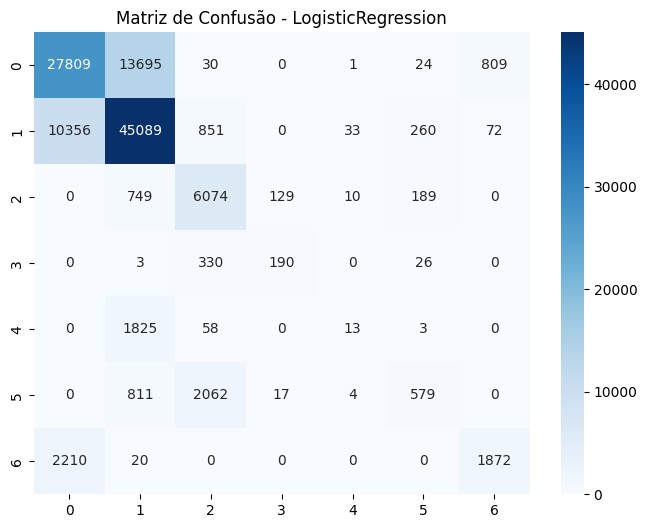

Treinando RandomForest...
RandomForest: Acc=0.9325, F1=0.8842, Train=127.90s, Inf=5.13s
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     42368
           1       0.93      0.96      0.94     56661
           2       0.91      0.93      0.92      7151
           3       0.87      0.72      0.79       549
           4       0.90      0.71      0.80      1899
           5       0.89      0.83      0.86      3473
           6       0.96      0.94      0.95      4102

    accuracy                           0.93    116203
   macro avg       0.91      0.86      0.88    116203
weighted avg       0.93      0.93      0.93    116203



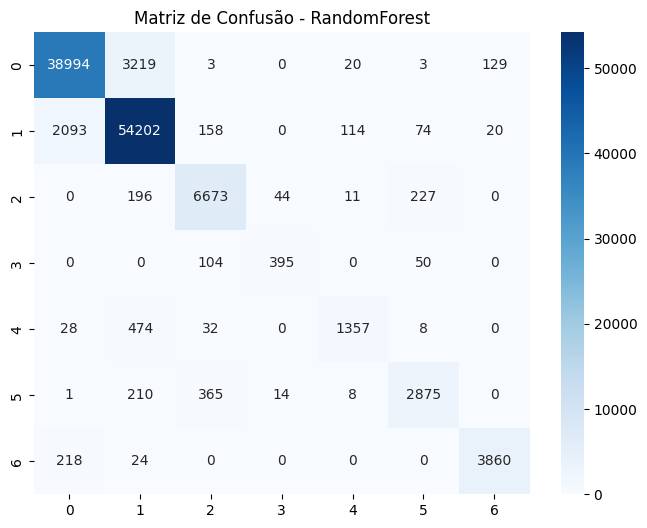

Treinando ExtraTrees...
ExtraTrees: Acc=0.9336, F1=0.8865, Train=96.03s, Inf=7.47s
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     42368
           1       0.93      0.96      0.94     56661
           2       0.91      0.94      0.92      7151
           3       0.88      0.72      0.79       549
           4       0.88      0.73      0.80      1899
           5       0.89      0.83      0.86      3473
           6       0.96      0.94      0.95      4102

    accuracy                           0.93    116203
   macro avg       0.91      0.86      0.89    116203
weighted avg       0.93      0.93      0.93    116203



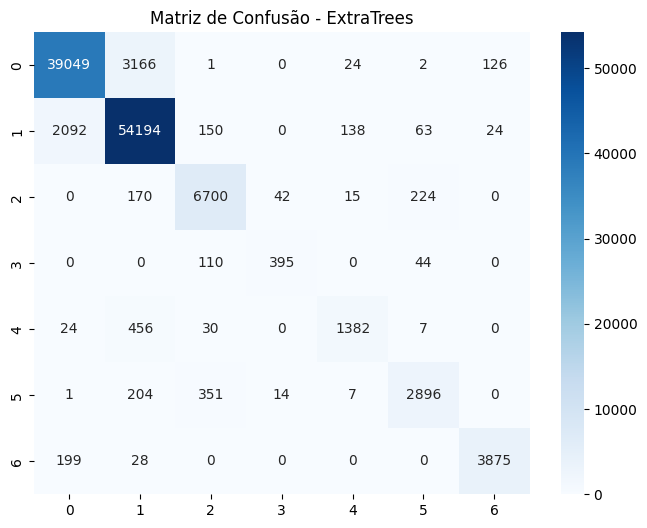

Treinando HistGradientBoosting...


  File "C:\Users\calab\anaconda3\envs\pycaret\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\calab\anaconda3\envs\pycaret\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\calab\anaconda3\envs\pycaret\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\calab\anaconda3\envs\pycaret\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


HistGradientBoosting: Acc=0.7610, F1=0.6768, Train=4.28s, Inf=0.25s
              precision    recall  f1-score   support

           0       0.75      0.72      0.73     42368
           1       0.77      0.82      0.79     56661
           2       0.77      0.82      0.79      7151
           3       0.71      0.55      0.62       549
           4       0.76      0.36      0.49      1899
           5       0.70      0.45      0.55      3473
           6       0.87      0.66      0.75      4102

    accuracy                           0.76    116203
   macro avg       0.76      0.63      0.68    116203
weighted avg       0.76      0.76      0.76    116203



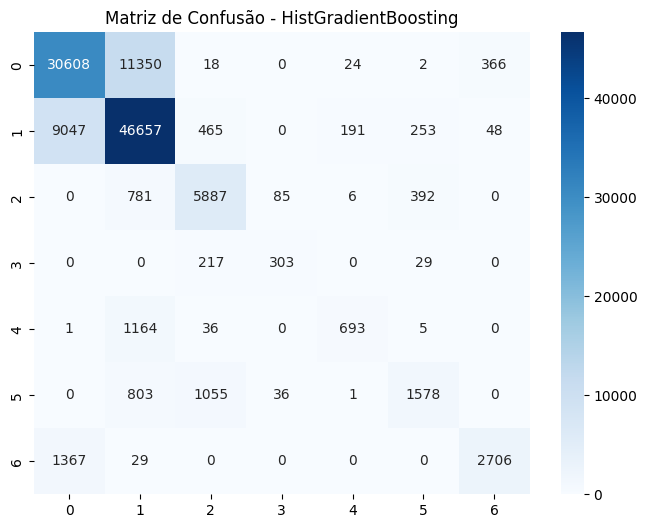

Treinando SGDClassifier...
SGDClassifier: Acc=0.6863, F1=0.4158, Train=7.95s, Inf=0.03s
              precision    recall  f1-score   support

           0       0.68      0.64      0.66     42368
           1       0.72      0.78      0.75     56661
           2       0.59      0.89      0.71      7151
           3       0.49      0.17      0.26       549
           4       0.00      0.00      0.00      1899
           5       0.23      0.05      0.08      3473
           6       0.57      0.38      0.46      4102

    accuracy                           0.69    116203
   macro avg       0.47      0.42      0.42    116203
weighted avg       0.66      0.69      0.67    116203



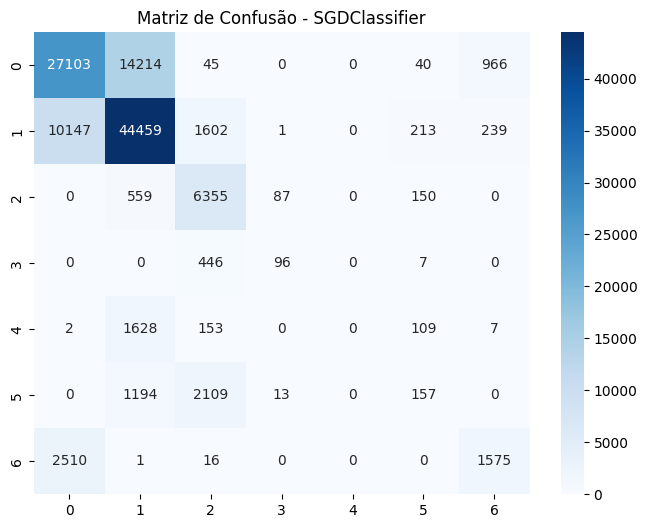

Treinando KNeighbors...
KNeighbors: Acc=0.8978, F1=0.8378, Train=0.10s, Inf=100.51s
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     42368
           1       0.90      0.92      0.91     56661
           2       0.87      0.89      0.88      7151
           3       0.83      0.68      0.75       549
           4       0.77      0.67      0.71      1899
           5       0.82      0.76      0.79      3473
           6       0.93      0.91      0.92      4102

    accuracy                           0.90    116203
   macro avg       0.86      0.82      0.84    116203
weighted avg       0.90      0.90      0.90    116203



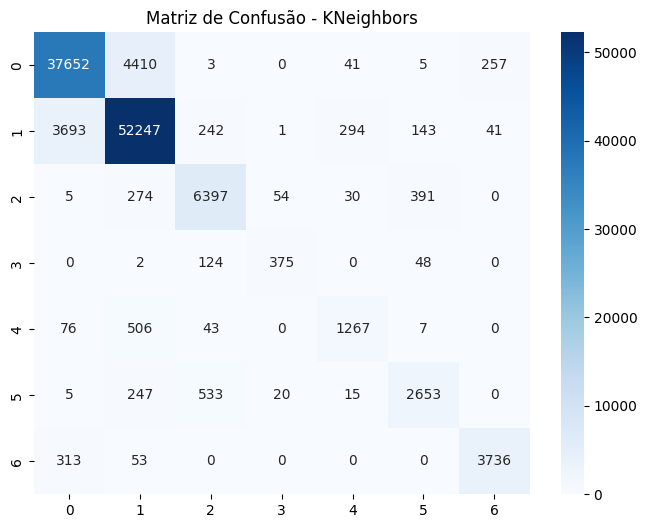

Treinando XGBClassifier...
XGBClassifier: Acc=0.8268, F1=0.7788, Train=14.63s, Inf=0.52s
              precision    recall  f1-score   support

           0       0.83      0.78      0.80     42368
           1       0.82      0.88      0.85     56661
           2       0.84      0.86      0.85      7151
           3       0.84      0.70      0.77       549
           4       0.83      0.46      0.59      1899
           5       0.78      0.67      0.72      3473
           6       0.92      0.83      0.87      4102

    accuracy                           0.83    116203
   macro avg       0.84      0.74      0.78    116203
weighted avg       0.83      0.83      0.83    116203



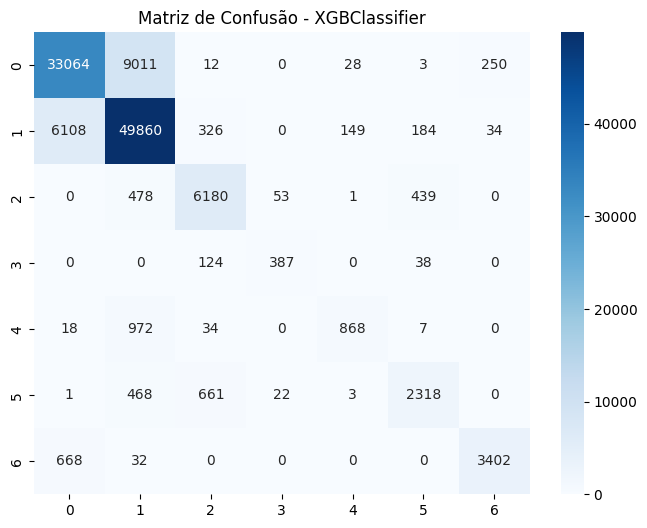

In [6]:
# Definição de modelos
models = {
    'LogisticRegression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),  # max_iter para convergência
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),  # 100 árvores
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE),  # Similar ao RF, mas mais aleatório
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),  # Boosting histograma-based
    'SGDClassifier': SGDClassifier(random_state=RANDOM_STATE, max_iter=1000),  # Gradiente descendente estocástico
    'KNeighbors': KNeighborsClassifier(n_neighbors=5)  # KNN com 5 vizinhos
}

if XGB_AVAILABLE:
    models['XGBClassifier'] = xgb.XGBClassifier(random_state=RANDOM_STATE, n_estimators=100)  # Boosting XGBoost

# Redes neurais se TF disponível
if TF_AVAILABLE:
    def build_mlp_shallow(input_dim):
        model = Sequential([
            Dense(64, activation='relu', input_dim=input_dim),
            Dense(7, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    
    def build_mlp_deep(input_dim):
        model = Sequential([
            Dense(128, activation='relu', input_dim=input_dim),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(7, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    
    def build_mlp_regularized(input_dim):
        model = Sequential([
            Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01), input_dim=input_dim),
            Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            Dense(7, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    
    models['MLP_Shallow'] = build_mlp_shallow(X_train_selected.shape[1])
    models['MLP_Deep'] = build_mlp_deep(X_train_selected.shape[1])
    models['MLP_Regularized'] = build_mlp_regularized(X_train_selected.shape[1])

# Treinamento e avaliação
results = []
for name, model in models.items():
    print(f'Treinando {name}...')
    start_train = time.time()
    if 'MLP' in name:
        # Para NN, usar callbacks
        callbacks = [EarlyStopping(monitor='val_loss', patience=5), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]
        model.fit(X_train_selected, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=callbacks, verbose=0)
    else:
        model.fit(X_train_selected, y_train)
    train_time = time.time() - start_train
    
    start_inf = time.time()
    y_pred = model.predict(X_test_selected)
    if 'MLP' in name:
        y_pred = np.argmax(y_pred, axis=1)
    inf_time = time.time() - start_inf
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results.append({
        'model': name,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1,
        'train_time': train_time,
        'inf_time': inf_time
    })
    
    print(f'{name}: Acc={acc:.4f}, F1={f1:.4f}, Train={train_time:.2f}s, Inf={inf_time:.2f}s')
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {name}')
    plt.show()


In [7]:
# Ranking final
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='f1_macro', ascending=False)
print('Ranking dos Modelos:')
print(df_results)


Ranking dos Modelos:


ModuleNotFoundError: No module named 'pandas.io.formats.string'

In [ ]:
# Seleção do melhor modelo
# Lógica: Priorizar f1_macro, depois accuracy, considerar tempo de treino/inferência, estabilidade e interpretabilidade.
# Escolher o topo, mas ajustar se custo alto (e.g., evitar NN se RF for próximo).
best_model_name = df_results.iloc[0]['model']
best_model = models[best_model_name]
print(f'Melhor modelo selecionado: {best_model_name}')


In [ ]:
# Salvamento de artefatos
os.makedirs('./artifacts', exist_ok=True)
joblib.dump(scaler, './artifacts/scaler.joblib')
with open('./artifacts/selected_features.json', 'w') as f:
    json.dump(selected_features, f)
if 'MLP' in best_model_name:
    best_model.save('./artifacts/best_model.keras')
else:
    joblib.dump(best_model, './artifacts/best_model.joblib')

# Metadata
metadata = {
    'dataset': 'Covertype',
    'best_model': best_model_name,
    'f1_macro': df_results.iloc[0]['f1_macro'],
    'accuracy': df_results.iloc[0]['accuracy'],
    'n_features': N_FEATURES,
    'modo_rapido': MODO_RAPIDO
}
with open('./artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f)
print('Artefatos salvos em ./artifacts/')


In [ ]:
# Exemplo de reutilização
print('Exemplo de reutilização do pipeline salvo:')
scaler_loaded, features_loaded, model_loaded = carregar_pipeline_salvo('./artifacts')
# Simular novos dados (usando parte do teste)
X_novo = X_test.iloc[:5]  # 5 amostras
predicoes = predizer_novos_dados(X_novo, scaler_loaded, features_loaded, model_loaded)
print('Predições para novos dados:', predicoes)
print('Labels reais:', y_test[:5])
